In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
import joblib

In [2]:
CLEAN_TMDB_FILE_PATH = "../datasets/clean/tmdb-movies/TMDB_movie_dataset_v11.csv"
CLEAN_MOVIELENS_RATINGS_PATH = "../datasets/clean/ml-32m/ratings.csv"

ML_API_TF_IDF_MATRIX_PATH = "../../ml-api/model/tf_idf_matrix.pkl"

In [3]:
tmdb = pd.read_csv(CLEAN_TMDB_FILE_PATH)
ratings = pd.read_csv(CLEAN_MOVIELENS_RATINGS_PATH)

In [4]:
tmdb_id_to_index = pd.Series(tmdb.index, index=tmdb["id"]).to_dict()
ratings["rating"] = ratings["rating"] - ratings["rating"].mean()

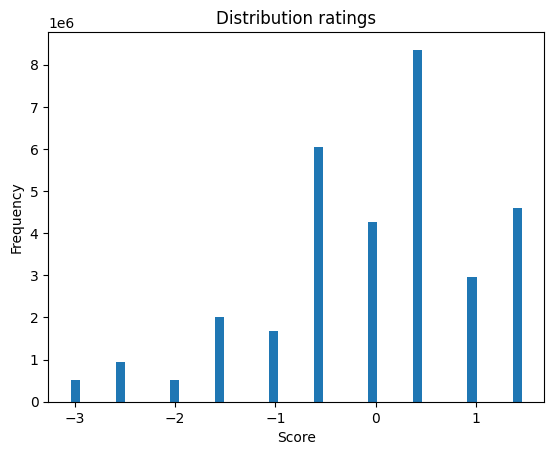

In [5]:
plt.hist(ratings["rating"], bins=50)
plt.title("Distribution ratings")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [6]:
print("min:", ratings["rating"].min())
print("max:", ratings["rating"].max())
print("mean:", ratings["rating"].mean())
print("std:", ratings["rating"].std())
print(np.percentile(ratings["rating"], [0, 25, 50, 75, 100]))

min: -3.0419925869439015
max: 1.4580074130560985
mean: -2.756102319345103e-16
std: 1.0581912389528363
[-3.04199259 -0.54199259 -0.04199259  0.45800741  1.45800741]


In [7]:
def find_in_dataset_by_substring(movie_names):
    found = []
    for movie_name in movie_names:
        results = tmdb[tmdb["title"].str.contains(movie_name, case=False, na=False)]
        haa = results.sort_values(by="popularity", ascending=False)[["id", "title"]]
        found.append(haa.values.tolist())
    return found

def find_in_dataset_by_id(movie_id):
    return tmdb[tmdb["id"] == movie_id]["title"].values[0]

def print_ratings_dict(ratings_dict: dict[int, int]):
    for id, rating in ratings_dict.items():
        print(f"id: {id}, name: {find_in_dataset_by_id(id)}, rating: {rating}")

In [8]:
find_in_dataset_by_substring(["justice", "batman", "superman", "flash", "lantern", "steel", "watchmen", "joker"])

[[[1003581, 'Justice League: Warworld'],
  [791373, "Zack Snyder's Justice League"],
  [141052, 'Justice League'],
  [209112, 'Batman v Superman: Dawn of Justice'],
  [297556, 'Justice League: Throne of Atlantis'],
  [14362, 'Out for Justice'],
  [183011, 'Justice League: The Flashpoint Paradox'],
  [997776, 'Justice League x RWBY: Super Heroes & Huntsmen, Part One'],
  [618344, 'Justice League Dark: Apokolips War'],
  [831405, 'Injustice'],
  [736069, 'Justice Society: World War II'],
  [663870, 'Riders of Justice'],
  [382512, 'LEGO DC Comics Super Heroes: Justice League: Cosmic Clash'],
  [150213, 'Pokémon the Movie: Kyurem vs. the Sword of Justice'],
  [323027, 'Justice League: Gods and Monsters'],
  [379291, 'Justice League vs. Teen Titans'],
  [14011, 'Justice League: The New Frontier'],
  [217993, 'Justice League: War'],
  [76589, 'Justice League: Doom'],
  [30061, 'Justice League: Crisis on Two Earths'],
  [17443, '...And Justice for All'],
  [408220, 'Justice League Dark'],
  

In [9]:
find_in_dataset_by_id(791373)

"Zack Snyder's Justice League"

In [10]:
marvel_fan_rd = {
  569094: 4.5,
  634649: 4,
  271110: 3,
  1771: 4,
  10138: 4.5,
  1724: 3.5,
  26881: 4,
  299536: 5,
  9320: 4.5
}

print_ratings_dict(marvel_fan_rd)
print()
print()
print()

marvel_fan_dc_hater_rd = {
  569094: 4.5,
  634649: 4,
  271110: 3,
  1771: 4,
  10138: 4.5,
  1724: 3.5,
  26881: 4,
  299536: 5,
  9320: 4.5,
  141052: 1,
  209112: 0,
  414906: 2.5,
  272: 1.4,
  1924: 1,
  298618: 0.7,
  44912: 0,
  49521: 1.8,
  13183: 0.3,
  475557: 3
}

print_ratings_dict(marvel_fan_dc_hater_rd)

id: 569094, name: Spider-Man: Across the Spider-Verse, rating: 4.5
id: 634649, name: Spider-Man: No Way Home, rating: 4
id: 271110, name: Captain America: Civil War, rating: 3
id: 1771, name: Captain America: The First Avenger, rating: 4
id: 10138, name: Iron Man 2, rating: 4.5
id: 1724, name: The Incredible Hulk, rating: 3.5
id: 26881, name: The Incredible Hulk Returns, rating: 4
id: 299536, name: Avengers: Infinity War, rating: 5
id: 9320, name: The Avengers, rating: 4.5



id: 569094, name: Spider-Man: Across the Spider-Verse, rating: 4.5
id: 634649, name: Spider-Man: No Way Home, rating: 4
id: 271110, name: Captain America: Civil War, rating: 3
id: 1771, name: Captain America: The First Avenger, rating: 4
id: 10138, name: Iron Man 2, rating: 4.5
id: 1724, name: The Incredible Hulk, rating: 3.5
id: 26881, name: The Incredible Hulk Returns, rating: 4
id: 299536, name: Avengers: Infinity War, rating: 5
id: 9320, name: The Avengers, rating: 4.5
id: 141052, name: Justice League, rating:

Collaborative filtering


In [11]:
ratings[ratings["tmdbId"].isna()]

,userId,rating,movieId,tmdbId


In [12]:
ratings[ratings["userId"].isna()]

,userId,rating,movieId,tmdbId


In [13]:
movie_stats = ratings.groupby("tmdbId").agg(
    avg=("rating", "mean"),
    count=("rating", "count")
)

good_movies = movie_stats[
    (movie_stats["count"] >= 0)
].index

ratings_filtered = ratings[ratings["tmdbId"].isin(good_movies)]

In [14]:
len(np.sort(ratings["tmdbId"].unique()))

43817

In [15]:
ratings_test = ratings_filtered


user_ids = np.sort(ratings_test["userId"].unique())
movie_ids = np.sort(ratings_test["tmdbId"].unique())

user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}

n_users = len(user_ids)
n_items = len(movie_ids)

rows = ratings_test["userId"].map(user_map)
cols = ratings_test["tmdbId"].map(movie_map)
data = ratings_test["rating"]

R = csr_matrix((data, (rows, cols)), shape=(n_users, n_items))

svd = TruncatedSVD(n_components=35)
U = svd.fit_transform(R)
V = svd.components_

In [16]:
U

array([[ 0.31014289, -0.44448128, -0.26028948, ...,  0.2364185 ,
         0.73713256, -0.60582139],
       [ 0.10252899,  0.98464728, -0.13173097, ...,  1.48016099,
        -0.11850211,  0.27995309],
       [ 1.39098001, -0.26788952,  0.55827144, ...,  0.66852895,
         1.42001791, -0.26379404],
       ...,
       [ 0.81901789,  0.68387642, -0.318833  , ...,  0.02779784,
         0.134247  ,  0.49074424],
       [ 1.59855487,  0.78694778,  0.75796324, ..., -0.2180029 ,
        -0.24219694, -0.74611283],
       [ 3.59022596,  1.82686106,  2.39621605, ...,  0.99610726,
         0.95431031, -0.52027149]], shape=(200948, 35))

In [17]:
V

array([[ 3.51711282e-04,  1.38121990e-04, -2.92794936e-03, ...,
         1.33889118e-05,  1.11638454e-05,  4.30413378e-06],
       [ 2.18268609e-04, -8.71286350e-05,  9.31238852e-03, ...,
        -6.94809419e-07,  2.99544829e-06,  2.85315159e-05],
       [-1.11626830e-03, -3.44942845e-04, -4.98812483e-03, ...,
         3.99663696e-05,  6.83694605e-06, -6.79791951e-05],
       ...,
       [-3.55814261e-04, -1.77883717e-04,  6.88831420e-03, ...,
        -2.08207826e-05,  2.59362252e-05,  1.14307930e-04],
       [-7.12172522e-07,  1.97674719e-05,  3.23803757e-03, ...,
        -1.02999358e-04, -2.66186275e-05, -5.55351926e-06],
       [ 8.51892580e-05,  1.49007071e-04, -2.70668111e-03, ...,
         1.80772907e-05,  7.11840579e-05, -7.63226199e-06]],
      shape=(35, 43817))

In [18]:
_indices = []
_ratings = []

for tmdb_id, rating in marvel_fan_rd.items():
    if tmdb_id in movie_map:
        _indices.append(movie_map[tmdb_id])
        _ratings.append(rating)
    
V_sub = V[:, _indices]
r = np.array(_ratings)
user_vector = np.linalg.lstsq(V_sub.T, r, rcond=None)[0]
scores = user_vector @ V
scores

array([ 2.94192889e-01,  1.83052433e-01, -4.57798705e+00, ...,
        3.23814920e-03,  4.81876464e-02,  1.68180092e-02], shape=(43817,))

In [19]:
print("min:", scores.min())
print("max:", scores.max())
print("mean:", scores.mean())
print("std:", scores.std())
print(np.percentile(scores, [0, 25, 50, 75, 100]))

min: -100.68941615683211
max: 100.9375743721792
mean: 0.019847545689515352
std: 2.928133448725105
[-1.00689416e+02 -1.38162264e-01 -1.75559479e-02  4.01282262e-02
  1.00937574e+02]


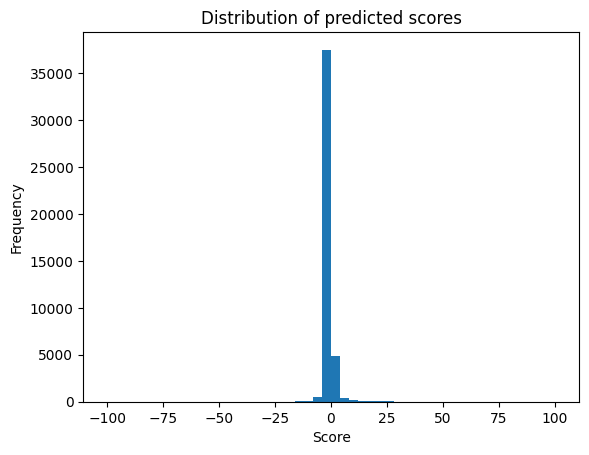

In [20]:
plt.hist(scores, bins=50)
plt.title("Distribution of predicted scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

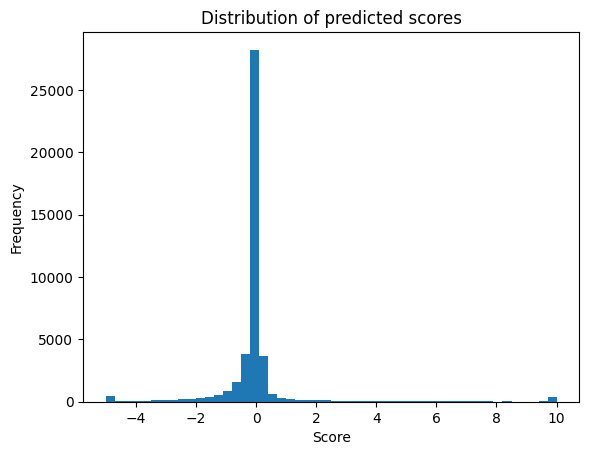

In [21]:
scores_cut = np.clip(scores, -5, 10)
plt.hist(scores_cut, bins=50)
plt.title("Distribution of predicted scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

In [22]:
top_k = 100

top_idx = scores.argsort()[::-1][:top_k]
top_movies = [(movie_ids[i], scores[i]) for i in top_idx]

results = []

tmdb_indexed = tmdb.set_index("id")

for movie_id, score in top_movies:
    if movie_id in tmdb_indexed.index:
        title = tmdb_indexed.loc[movie_id]["title"]
        results.append((title, score))

results

[('The Incredibles', np.float64(100.9375743721792)),
 ('Finding Nemo', np.float64(99.27994954596973)),
 ('Monsters, Inc.', np.float64(97.17842058732171)),
 ('WALL·E', np.float64(84.70091072406133)),
 ('Up', np.float64(81.55299627380155)),
 ('Shrek', np.float64(77.17082395830536)),
 ('Kill Bill: Vol. 1', np.float64(73.58430348691793)),
 ('Toy Story', np.float64(71.40568703197322)),
 ('The Matrix', np.float64(71.35978209034242)),
 ('Ratatouille', np.float64(71.2682626754801)),
 ('Kill Bill: Vol. 2', np.float64(66.34296104443267)),
 ('The Silence of the Lambs', np.float64(63.382044795645264)),
 ('Spirited Away', np.float64(57.92598931439182)),
 ('Toy Story 3', np.float64(57.617475779140875)),
 ('2001: A Space Odyssey', np.float64(52.23834115342161)),
 ('Shrek 2', np.float64(51.64295707706996)),
 ('Mad Max: Fury Road', np.float64(50.479000247078204)),
 ('Inside Out', np.float64(49.8570818485231)),
 ('Inglourious Basterds', np.float64(48.89057683033243)),
 ('The Matrix Revolutions', np.floa